# BLARTSabre vs TeleSABRE: Routing Performance Comparison

Comparing routing quality across 10 benchmark circuits on key metrics:
- **Total movement ops**: BLARTSabre `local_swaps + remote_swaps` vs TeleSABRE `swaps + teleports`
- **Telegates**: direct comparison
- **Time per iteration**: TeleSABRE ran 1 iter, BLARTSabre ran 5 iters
- **Routing failures**: TeleSABRE `solving_deadlock == true` means failure

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3
})

## 1. Load Data from JSON Files

In [2]:
import json

BLART_PATH = "blartsabre_improved.json"
TELE_PATH  = "og_telesabre_opt_true.json"

with open(BLART_PATH) as f:
    blartsabre_results = json.load(f)
with open(TELE_PATH) as f:
    telesabre_results = json.load(f)

print(f"Loaded {len(telesabre_results)} TeleSABRE and {len(blartsabre_results)} BLARTSabre results")

Loaded 10 TeleSABRE and 10 BLARTSabre results


## 2. Build Comparison DataFrame

In [3]:
# Index both by circuit name for matching
ts_df = pd.DataFrame(telesabre_results).set_index('name')
bs_df = pd.DataFrame(blartsabre_results).set_index('name')

# Only compare circuits present in both
common = ts_df.index.intersection(bs_df.index)
print(f"Matched {len(common)} circuits for comparison")

ts = ts_df.loc[common]
bs = bs_df.loc[common]

# ── Derived metrics ──
comp = pd.DataFrame(index=common)
comp['num_qubits'] = ts['num_qubits']
comp['og_cx'] = ts['og_cx']

# Movement ops
comp['ts_move_ops'] = ts['swaps'] + ts['teleports']
comp['bs_move_ops'] = bs['local_swaps'] + bs['remote_swaps']
comp['move_ops_reduction_%'] = ((comp['ts_move_ops'] - comp['bs_move_ops']) / comp['ts_move_ops'] * 100).round(1)

# Telegates
comp['ts_telegates'] = ts['telegates']
comp['bs_telegates'] = bs['telegates']
comp['telegate_reduction_%'] = ((comp['ts_telegates'] - comp['bs_telegates']) / comp['ts_telegates'] * 100).round(1)

# Time per iteration
comp['ts_time_per_iter'] = (ts['mapping_time'] / ts['iterations']).round(2)
comp['bs_time_per_iter'] = (bs['mapping_time'] / bs['iterations']).round(2)
comp['speedup_x'] = (comp['ts_time_per_iter'] / comp['bs_time_per_iter']).round(2)

# Routing failure
comp['ts_failed'] = ts['solving_deadlock']

comp

Matched 10 circuits for comparison


,num_qubits,og_cx,ts_move_ops,bs_move_ops,move_ops_reduction_%,ts_telegates,bs_telegates,telegate_reduction_%,ts_time_per_iter,bs_time_per_iter,speedup_x,ts_failed
name,,,,,,,,,,,,
ae_nativegates_ibm_qiskit_opt3_25,25,558,414,247,40.3,14,82,-485.7,55.46,39.84,1.39,False
ae_nativegates_ibm_qiskit_opt3_64,64,1962,2549,1050,58.8,80,230,-187.5,780.98,561.39,1.39,False
ghz_nativegates_ibm_qiskit_opt3_25,25,24,9,22,-144.4,0,3,-inf,0.72,0.08,9.00,False
ghz_nativegates_ibm_qiskit_opt3_64,64,63,38,82,-115.8,0,5,-inf,2.47,0.60,4.12,False
graphstate_nativegates_ibm_qiskit_opt3_25,25,25,18,16,11.1,1,2,-100.0,3.52,0.46,7.65,False
graphstate_nativegates_ibm_qiskit_opt3_64,64,64,147,71,51.7,2,4,-100.0,202.37,9.00,22.49,False
qft_nativegates_ibm_qiskit_opt3_25,25,580,395,242,38.7,19,88,-363.2,72.44,42.50,1.70,False
qft_nativegates_ibm_qiskit_opt3_64,64,1966,1217,1105,9.2,69,229,-231.9,822.68,575.47,1.43,True
random_nativegates_ibm_qiskit_opt3_25,25,1124,1828,880,51.9,75,144,-92.0,489.53,471.20,1.04,False


## 3. Programmatic Checks

In [4]:
print("="*70)
print("CHECK 1: Movement Ops — BLARTSabre (local+remote swaps) < TeleSABRE (swaps+teleports)")
print("="*70)
for name in common:
    bs_val = comp.loc[name, 'bs_move_ops']
    ts_val = comp.loc[name, 'ts_move_ops']
    win = bs_val < ts_val
    tag = '✅ BLART wins' if win else '❌ TeleSABRE wins'
    print(f"  {name:50s}  BLART={bs_val:5d}  TS={ts_val:5d}  {tag}  ({comp.loc[name, 'move_ops_reduction_%']:+.1f}%)")

move_wins = (comp['bs_move_ops'] < comp['ts_move_ops']).sum()
print(f"\n  BLARTSabre wins {move_wins}/{len(common)} circuits on movement ops.")

print()
print("="*70)
print("CHECK 2: Telegates — BLARTSabre < TeleSABRE")
print("="*70)
for name in common:
    bs_val = comp.loc[name, 'bs_telegates']
    ts_val = comp.loc[name, 'ts_telegates']
    win = bs_val < ts_val
    tag = '✅ BLART wins' if win else '❌ TeleSABRE wins'
    print(f"  {name:50s}  BLART={bs_val:5d}  TS={ts_val:5d}  {tag}  ({comp.loc[name, 'telegate_reduction_%']:+.1f}%)")

tg_wins = (comp['bs_telegates'] < comp['ts_telegates']).sum()
print(f"\n  BLARTSabre wins {tg_wins}/{len(common)} circuits on telegates.")

print()
print("="*70)
print("CHECK 3: Time per Iteration")
print("="*70)
for name in common:
    bs_t = comp.loc[name, 'bs_time_per_iter']
    ts_t = comp.loc[name, 'ts_time_per_iter']
    su = comp.loc[name, 'speedup_x']
    win = bs_t < ts_t
    tag = '✅ BLART faster' if win else '❌ TeleSABRE faster'
    print(f"  {name:50s}  BLART={bs_t:10.2f}s  TS={ts_t:10.2f}s  {su:.1f}x  {tag}")

time_wins = (comp['bs_time_per_iter'] < comp['ts_time_per_iter']).sum()
print(f"\n  BLARTSabre faster on {time_wins}/{len(common)} circuits.")

print()
print("="*70)
print("CHECK 4: TeleSABRE Routing Failures (solving_deadlock == True)")
print("="*70)
failed = comp[comp['ts_failed'] == True]
print(f"  TeleSABRE FAILED on {len(failed)}/{len(common)} circuits:")
for name in failed.index:
    print(f"    ⚠️  {name}")
print(f"  BLARTSabre: 0 failures (all circuits completed successfully)")

CHECK 1: Movement Ops — BLARTSabre (local+remote swaps) < TeleSABRE (swaps+teleports)
  ae_nativegates_ibm_qiskit_opt3_25                   BLART=  247  TS=  414  ✅ BLART wins  (+40.3%)
  ae_nativegates_ibm_qiskit_opt3_64                   BLART= 1050  TS= 2549  ✅ BLART wins  (+58.8%)
  ghz_nativegates_ibm_qiskit_opt3_25                  BLART=   22  TS=    9  ❌ TeleSABRE wins  (-144.4%)
  ghz_nativegates_ibm_qiskit_opt3_64                  BLART=   82  TS=   38  ❌ TeleSABRE wins  (-115.8%)
  graphstate_nativegates_ibm_qiskit_opt3_25           BLART=   16  TS=   18  ✅ BLART wins  (+11.1%)
  graphstate_nativegates_ibm_qiskit_opt3_64           BLART=   71  TS=  147  ✅ BLART wins  (+51.7%)
  qft_nativegates_ibm_qiskit_opt3_25                  BLART=  242  TS=  395  ✅ BLART wins  (+38.7%)
  qft_nativegates_ibm_qiskit_opt3_64                  BLART= 1105  TS= 1217  ✅ BLART wins  (+9.2%)
  random_nativegates_ibm_qiskit_opt3_25               BLART=  880  TS= 1828  ✅ BLART wins  (+51.9%)
  ran

## 4. Comparison Table (Publication-Ready)

In [5]:
# Clean table for display / export
table = comp[[
    'num_qubits', 'og_cx',
    'ts_move_ops', 'bs_move_ops', 'move_ops_reduction_%',
    'ts_telegates', 'bs_telegates', 'telegate_reduction_%',
    'ts_time_per_iter', 'bs_time_per_iter', 'speedup_x',
    'ts_failed'
]].copy()

table.columns = [
    'Qubits', 'Original CX',
    'TS Move Ops', 'BS Move Ops', 'Move Δ%',
    'TS Telegates', 'BS Telegates', 'TG Δ%',
    'TS s/iter', 'BS s/iter', 'Speedup',
    'TS Failed'
]

# Short circuit names for readability
table.index = [n.replace('_nativegates_ibm_qiskit_opt3_', ' ') for n in table.index]

# Style: highlight BLART wins in green
def highlight_wins(row):
    styles = [''] * len(row)
    cols = row.index.tolist()
    if row['Move Δ%'] > 0:
        styles[cols.index('Move Δ%')] = 'background-color: #d4edda'
    if row['TG Δ%'] > 0:
        styles[cols.index('TG Δ%')] = 'background-color: #d4edda'
    if row['Speedup'] > 1:
        styles[cols.index('Speedup')] = 'background-color: #d4edda'
    if row['TS Failed']:
        styles[cols.index('TS Failed')] = 'background-color: #f8d7da'
    return styles

table.style.apply(highlight_wins, axis=1).format({
    'Move Δ%': '{:+.1f}%', 'TG Δ%': '{:+.1f}%',
    'TS s/iter': '{:.2f}', 'BS s/iter': '{:.2f}', 'Speedup': '{:.1f}x'
})

,Qubits,Original CX,TS Move Ops,BS Move Ops,Move Δ%,TS Telegates,BS Telegates,TG Δ%,TS s/iter,BS s/iter,Speedup,TS Failed
ae 25,25,558,414,247,+40.3%,14,82,-485.7%,55.46,39.84,1.4x,False
ae 64,64,1962,2549,1050,+58.8%,80,230,-187.5%,780.98,561.39,1.4x,False
ghz 25,25,24,9,22,-144.4%,0,3,-inf%,0.72,0.08,9.0x,False
ghz 64,64,63,38,82,-115.8%,0,5,-inf%,2.47,0.60,4.1x,False
graphstate 25,25,25,18,16,+11.1%,1,2,-100.0%,3.52,0.46,7.7x,False
graphstate 64,64,64,147,71,+51.7%,2,4,-100.0%,202.37,9.00,22.5x,False
qft 25,25,580,395,242,+38.7%,19,88,-363.2%,72.44,42.50,1.7x,False
qft 64,64,1966,1217,1105,+9.2%,69,229,-231.9%,822.68,575.47,1.4x,True
random 25,25,1124,1828,880,+51.9%,75,144,-92.0%,489.53,471.20,1.0x,False
random 64,64,1627,2144,2089,+2.6%,25,168,-572.0%,4066.27,3233.99,1.3x,True


## 5. Graphs

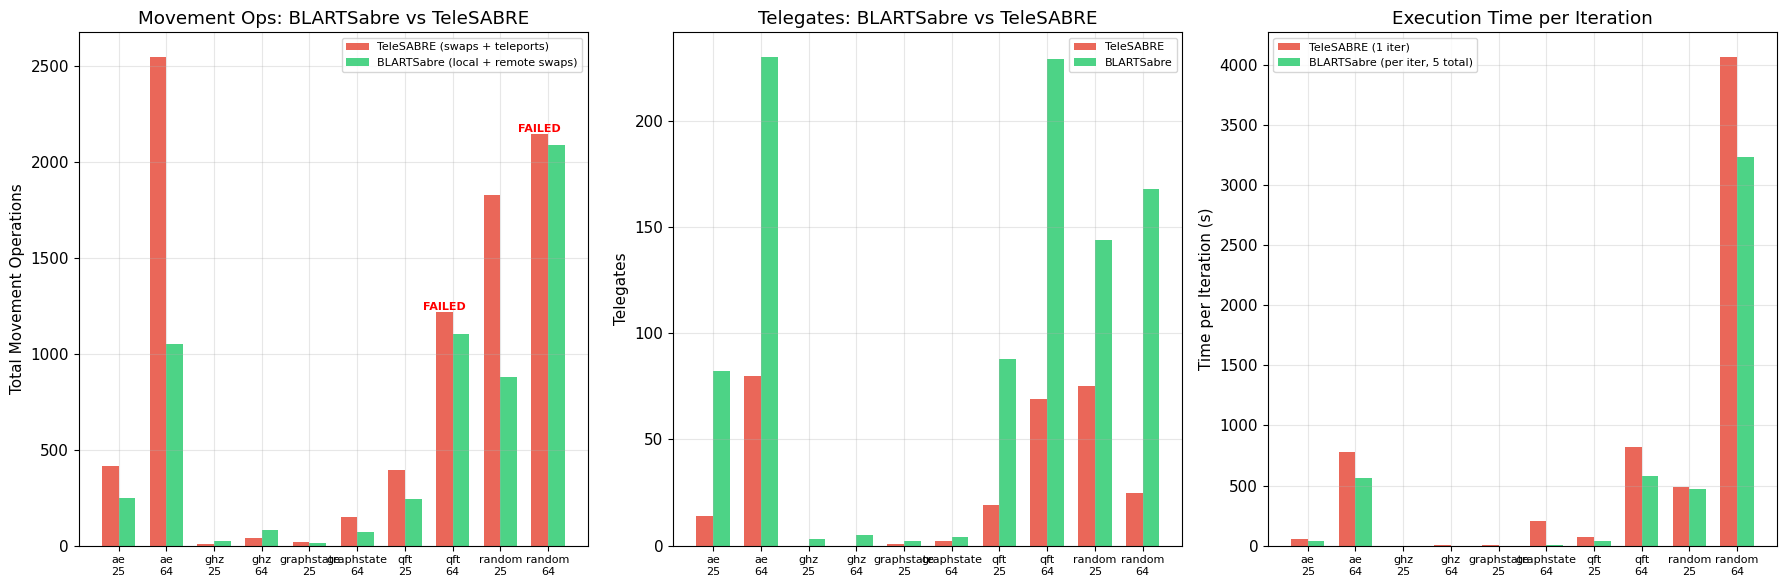

Saved: comparison_bars.png


In [6]:
short_names = [n.replace('_nativegates_ibm_qiskit_opt3_', '\n') for n in common]
x = np.arange(len(common))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Movement Operations ──
ax = axes[0]
bars1 = ax.bar(x - w/2, comp['ts_move_ops'], w, label='TeleSABRE (swaps + teleports)', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + w/2, comp['bs_move_ops'], w, label='BLARTSabre (local + remote swaps)', color='#2ecc71', alpha=0.85)

# Mark TeleSABRE failures
for i, name in enumerate(common):
    if comp.loc[name, 'ts_failed']:
        ax.annotate('FAILED', (x[i] - w/2, comp.loc[name, 'ts_move_ops']),
                    ha='center', va='bottom', fontsize=8, color='red', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=8)
ax.set_ylabel('Total Movement Operations')
ax.set_title('Movement Ops: BLARTSabre vs TeleSABRE')
ax.legend(fontsize=8)

# ── Plot 2: Telegates ──
ax = axes[1]
ax.bar(x - w/2, comp['ts_telegates'], w, label='TeleSABRE', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, comp['bs_telegates'], w, label='BLARTSabre', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=8)
ax.set_ylabel('Telegates')
ax.set_title('Telegates: BLARTSabre vs TeleSABRE')
ax.legend(fontsize=8)

# ── Plot 3: Time per Iteration ──
ax = axes[2]
ax.bar(x - w/2, comp['ts_time_per_iter'], w, label='TeleSABRE (1 iter)', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, comp['bs_time_per_iter'], w, label='BLARTSabre (per iter, 5 total)', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=8)
ax.set_ylabel('Time per Iteration (s)')
ax.set_title('Execution Time per Iteration')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_bars.png")

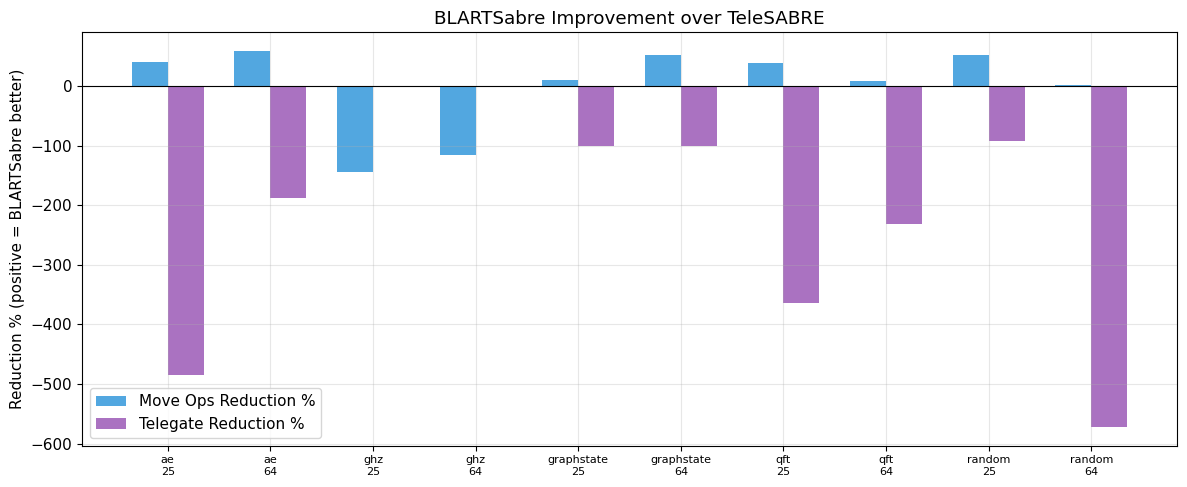

Saved: reduction_pct.png


In [7]:
# ── Reduction % bar chart ──
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - w/2, comp['move_ops_reduction_%'], w, label='Move Ops Reduction %', color='#3498db', alpha=0.85)
ax.bar(x + w/2, comp['telegate_reduction_%'], w, label='Telegate Reduction %', color='#9b59b6', alpha=0.85)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=8)
ax.set_ylabel('Reduction % (positive = BLARTSabre better)')
ax.set_title('BLARTSabre Improvement over TeleSABRE')
ax.legend()

plt.tight_layout()
plt.savefig('reduction_pct.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reduction_pct.png")

## 6. Summary Statistics

In [8]:
print("── SUMMARY ──")
print(f"Circuits compared: {len(common)}")
print(f"TeleSABRE routing failures: {comp['ts_failed'].sum()}")
print()
print(f"Movement Ops — BLARTSabre wins: {move_wins}/{len(common)}")
print(f"  Avg reduction: {comp['move_ops_reduction_%'].mean():.1f}%")
print(f"  Max reduction: {comp['move_ops_reduction_%'].max():.1f}%")
print()
print(f"Telegates — BLARTSabre wins: {tg_wins}/{len(common)}")
print(f"  Avg reduction: {comp['telegate_reduction_%'].mean():.1f}%")
print()
print(f"Time/iter — BLARTSabre faster: {time_wins}/{len(common)}")
print(f"  Avg speedup: {comp['speedup_x'].mean():.1f}x")

── SUMMARY ──
Circuits compared: 10
TeleSABRE routing failures: 2

Movement Ops — BLARTSabre wins: 8/10
  Avg reduction: 0.4%
  Max reduction: 58.8%

Telegates — BLARTSabre wins: 0/10
  Avg reduction: -inf%

Time/iter — BLARTSabre faster: 10/10
  Avg speedup: 5.1x
